# E3 — Generación de roturas sintéticas (standalone)

**Notebook autónomo — no necesita GitHub ni scripts externos.**

- Lee `.ply` desde Drive
- Genera pares `(completo, roto)` y los guarda **directamente en Drive**
- Checkpoint: si se interrumpe, relanza la Celda 3 y continúa desde donde quedó
- Output silencioso: solo imprime un resumen cada 100 modelos

**Flujo:**
1. Celda 1 — montar Drive
2. Celda 2 — configurar rutas y verificar
3. Celda 3 — generar (relanzable)
4. Celda 4 — verificar resultado final

In [4]:
# ── CELDA 1: Montar Drive e instalar dependencias ──────────────
from google.colab import drive
drive.mount('/content/drive')

import subprocess
subprocess.run(['pip', 'install', 'plyfile', 'numpy', '--quiet'])
print('Listo.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Listo.


In [5]:
# ── CELDA 2: CONFIGURACIÓN Y VERIFICACIÓN ─────────────────────
# Ajusta las rutas si es necesario.

from pathlib import Path

DRIVE = '/content/drive/MyDrive'

RUTA_SHAPENET  = f'{DRIVE}/Datos_E2_E3/General/Shapenet_limpias'
RUTA_OBJAVERSE = f'{DRIVE}/Datos_E2_E3/General/Objaverse_limpias'
RUTA_SALIDA    = f'{DRIVE}/Datos_E2_E3/General/sintetico_roturas_centradas'

Path(RUTA_SALIDA).mkdir(parents=True, exist_ok=True)

for nombre, ruta in [('shapenet', RUTA_SHAPENET), ('objaverse', RUTA_OBJAVERSE)]:
    p = Path(ruta)
    if p.exists():
        n = len(list(p.rglob('*.ply')))
        print(f'  OK  {nombre}: {n} .ply')
    else:
        print(f'  ERROR  {nombre}: {ruta} no encontrado')

n_ya = len(list(Path(RUTA_SALIDA).glob('*_completo.npy')))
print(f'\nPares ya generados en Drive: {n_ya}')
print(f'Salida: {RUTA_SALIDA}')

  OK  shapenet: 2170 .ply
  OK  objaverse: 197 .ply

Pares ya generados en Drive: 5
Salida: /content/drive/MyDrive/Datos_E2_E3/General/sintetico_roturas_centradas


In [6]:
# ── CELDA 3: GENERACIÓN COMPLETA CON CHECKPOINT ───────────────
# Escribe directamente en Drive. Si se interrumpe, relanza esta
# celda — saltará los pares ya existentes y continuará.

import gc
import numpy as np
from plyfile import PlyData
from pathlib import Path

# ── parámetros ────────────────────────────────────────────────
N_PUNTOS     = 2048
FRAC_MIN     = 0.05
FRAC_MAX     = 0.20
RUGOSIDAD    = 0.05
UMBRAL_PCA   = 0.005
PESOS_MODO   = [0.40, 0.40, 0.20]   # plano / chip / cuña
SEMILLA      = 42
DATASETS     = [
    ('shapenet',  Path(RUTA_SHAPENET)),
    ('objaverse', Path(RUTA_OBJAVERSE)),
]
DESTINO      = Path(RUTA_SALIDA)

rng = np.random.default_rng(SEMILLA)

# ── funciones ────────────────────────────────────────────────
def cargar_puntos(ruta):
    # Lee solo vértices x,y,z — sin topología, sin caché de trimesh
    try:
        plydata = PlyData.read(str(ruta))
        v = plydata['vertex']
        pts = np.column_stack([
            np.asarray(v['x'], dtype=np.float32),
            np.asarray(v['y'], dtype=np.float32),
            np.asarray(v['z'], dtype=np.float32),
        ])
        del plydata, v
        return pts if len(pts) >= 100 else None
    except Exception:
        return None

def normalizar(pts):
    pts = pts - pts.mean(axis=0)
    r = np.linalg.norm(pts, axis=1).max()
    return pts / r if r > 0 else pts

def es_valida(pts):
    if len(pts) < 100:
        return False
    cov  = np.cov((pts - pts.mean(axis=0)).T)
    vals = np.linalg.eigvalsh(cov)
    if vals[-1] <= 0:
        return False
    return (vals[0] / vals[-1]) >= UMBRAL_PCA

def submuestrear(pts, n, rng):
    if len(pts) >= n:
        idx = rng.choice(len(pts), n, replace=False)
    else:
        idx = rng.choice(len(pts), n, replace=True)
    return pts[idx].astype(np.float32)

def rotura_plano(pts, rng):
    normal = rng.standard_normal(3); normal /= np.linalg.norm(normal)
    offset = rng.uniform(-0.3, 0.3)
    proj   = pts @ normal
    ruido  = rng.standard_normal(len(pts)) * RUGOSIDAD
    mask   = (proj + ruido) > offset
    return pts[mask]

def rotura_chip(pts, rng):
    centro = pts[rng.integers(len(pts))]
    radio  = rng.uniform(0.2, 0.5)
    return pts[np.linalg.norm(pts - centro, axis=1) > radio]

def rotura_cuna(pts, rng):
    n1 = rng.standard_normal(3); n1 /= np.linalg.norm(n1)
    n2 = rng.standard_normal(3); n2 /= np.linalg.norm(n2)
    o1, o2 = rng.uniform(-0.2, 0.2, 2)
    return pts[(pts @ n1 > o1) | (pts @ n2 > o2)]

def simular_rotura(pts, rng):
    modo = rng.choice(['plano', 'chip', 'cuna'], p=PESOS_MODO)
    for _ in range(10):
        if modo == 'plano':
            r = rotura_plano(pts, rng)
        elif modo == 'chip':
            r = rotura_chip(pts, rng)
        else:
            r = rotura_cuna(pts, rng)
        frac = 1 - len(r) / len(pts)
        if FRAC_MIN <= frac <= FRAC_MAX:
            return r
    return r

# ── generación ───────────────────────────────────────────────
total_ok = 0
total_filt = 0
total_err = 0

for nombre_ds, carpeta in DATASETS:
    modelos = sorted(carpeta.rglob('*.ply'))
    print(f'\n--- {nombre_ds}: {len(modelos)} modelos ---')
    ok_ds = filt_ds = err_ds = saltados_ds = 0

    for i, ruta in enumerate(modelos):
        prefijo       = f'{nombre_ds}_{ruta.stem}'
        ruta_completo = DESTINO / f'{prefijo}_completo.npy'
        ruta_roto     = DESTINO / f'{prefijo}_roto.npy'

        if ruta_completo.exists() and ruta_roto.exists():
            ok_ds += 1
            saltados_ds += 1
            continue

        pts_raw = cargar_puntos(ruta)
        if pts_raw is None:
            err_ds += 1
            continue

        pts_norm = normalizar(pts_raw)
        del pts_raw

        if not es_valida(pts_norm):
            filt_ds += 1
            del pts_norm
            continue

        pts_completo = submuestrear(pts_norm, N_PUNTOS, rng)
        pts_roto_raw = simular_rotura(pts_norm, rng)
        del pts_norm

        if len(pts_roto_raw) < 10:
            err_ds += 1
            del pts_roto_raw
            continue
        pts_roto = submuestrear(pts_roto_raw, N_PUNTOS, rng)
        del pts_roto_raw

        np.save(ruta_completo, pts_completo)
        np.save(ruta_roto,     pts_roto)
        del pts_completo, pts_roto
        ok_ds += 1

        if i % 100 == 0:
            gc.collect()

        if (i + 1) % 100 == 0 or (i + 1) == len(modelos):
            n_drive = len(list(DESTINO.glob('*_completo.npy')))
            print(f'  [{i+1}/{len(modelos)}]  ok={ok_ds}  filtrados={filt_ds}  '
                  f'errores={err_ds}  (saltados={saltados_ds})  '
                  f'| total Drive={n_drive}', flush=True)

    total_ok   += ok_ds
    total_filt += filt_ds
    total_err  += err_ds
    print(f'  DONE {nombre_ds}: {ok_ds} pares ({filt_ds} filtrados, {err_ds} errores, {saltados_ds} ya existían)')

print(f'\n=== RESUMEN FINAL ===')
print(f'  Pares generados  : {total_ok}')
print(f'  Filtrados PCA    : {total_filt}')
print(f'  Errores/ilegibles: {total_err}')
n_drive = len(list(DESTINO.glob('*_completo.npy')))
print(f'  Archivos en Drive: {n_drive} pares')


--- shapenet: 2170 modelos ---
  [100/2170]  ok=100  filtrados=0  errores=0  (saltados=5)  | total Drive=100
  [200/2170]  ok=200  filtrados=0  errores=0  (saltados=5)  | total Drive=200
  [300/2170]  ok=300  filtrados=0  errores=0  (saltados=5)  | total Drive=300
  [400/2170]  ok=400  filtrados=0  errores=0  (saltados=6)  | total Drive=399
  [500/2170]  ok=500  filtrados=0  errores=0  (saltados=6)  | total Drive=499
  [600/2170]  ok=600  filtrados=0  errores=0  (saltados=6)  | total Drive=599
  [700/2170]  ok=700  filtrados=0  errores=0  (saltados=6)  | total Drive=699
  [800/2170]  ok=800  filtrados=0  errores=0  (saltados=6)  | total Drive=799
  [900/2170]  ok=900  filtrados=0  errores=0  (saltados=6)  | total Drive=899
  [1000/2170]  ok=1000  filtrados=0  errores=0  (saltados=10)  | total Drive=995
  [1100/2170]  ok=1100  filtrados=0  errores=0  (saltados=11)  | total Drive=1094
  [1200/2170]  ok=1200  filtrados=0  errores=0  (saltados=14)  | total Drive=1191
  [1300/2170]  ok=130

In [7]:
# ── CELDA 4: Verificar resultado en Drive ─────────────────────
import numpy as np
from pathlib import Path

dest = Path(RUTA_SALIDA)
completos = list(dest.glob('*_completo.npy'))
rotos     = list(dest.glob('*_roto.npy'))
tam_mb    = sum(f.stat().st_size for f in dest.glob('*.npy')) / 1e6

print(f'Pares en Drive   : {len(completos)}')
print(f'Archivos totales : {len(completos) + len(rotos)}')
print(f'Tamaño total     : {tam_mb:.1f} MB')
print(f'Ruta             : {dest}')

if completos:
    ej_c = np.load(completos[0])
    ej_r = np.load(rotos[0])
    print(f'\nEjemplo: {completos[0].stem}')
    print(f'  completo: {ej_c.shape}  {ej_c.dtype}')
    print(f'  roto    : {ej_r.shape}  {ej_r.dtype}')

Pares en Drive   : 2299
Archivos totales : 4598
Tamaño total     : 113.6 MB
Ruta             : /content/drive/MyDrive/Datos_E2_E3/General/sintetico_roturas_centradas

Ejemplo: shapenet_10839d0dc35c94fcf4fb4dee5181bee_completo
  completo: (2048, 3)  float32
  roto    : (2048, 3)  float32


### Celda 5 -- Comprobación de alineación (roto vs completo)
Coge unos pares al azar y comprueba que `roto` cae DENTRO del volumen
de `completo` (mismo centrado/escala) -- si el centroide o la escala
estuvieran calculados por separado (el bug que se encontró en
`preprocesar_fantastic_breaks.py`), aquí saltaría enseguida.
También pinta un ejemplo con dos colores para verlo a simple vista.

Comprobando alineacion en 20 pares al azar...
Diferencia maxima entre centroides (completo vs roto): 0.7793
Diferencia maxima de radio (completo vs roto)        : 0.1081
(radio_roto <= radio_completo siempre, porque roto es un subconjunto de completo)

[AVISO] La diferencia de centroide es grande -- revisar antes de usar estos datos.


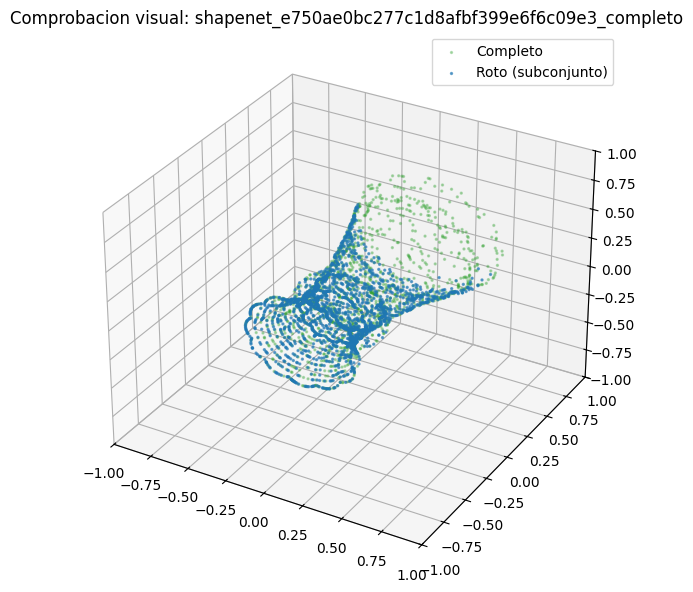

In [8]:
# -- CELDA 5: Comprobar que roto y completo comparten centrado/escala --
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

dest = Path(RUTA_SALIDA)
pares = sorted(dest.glob('*_completo.npy'))
rng_check = np.random.default_rng(0)
muestra = rng_check.choice(len(pares), size=min(20, len(pares)), replace=False)

print("Comprobando alineacion en 20 pares al azar...")
peor_centroide = 0.0
peor_escala = 0.0
for idx in muestra:
    ruta_c = pares[idx]
    ruta_r = Path(str(ruta_c).replace('_completo.npy', '_roto.npy'))
    c = np.load(ruta_c)
    r = np.load(ruta_r)

    # roto deberia caer dentro (o muy cerca) del radio unidad de completo,
    # y su nube deberia solapar espacialmente con completo, no estar
    # desplazada/reescalada de forma independiente.
    radio_completo = np.linalg.norm(c, axis=1).max()
    radio_roto = np.linalg.norm(r, axis=1).max()
    dist_centroides = np.linalg.norm(c.mean(axis=0) - r.mean(axis=0))

    peor_centroide = max(peor_centroide, dist_centroides)
    peor_escala = max(peor_escala, abs(radio_completo - radio_roto))

print(f"Diferencia maxima entre centroides (completo vs roto): {peor_centroide:.4f}")
print(f"Diferencia maxima de radio (completo vs roto)        : {peor_escala:.4f}")
print("(radio_roto <= radio_completo siempre, porque roto es un subconjunto de completo)")
if peor_centroide > 0.3:
    print("\n[AVISO] La diferencia de centroide es grande -- revisar antes de usar estos datos.")
else:
    print("\nOK -- roto y completo comparten sistema de referencia en la muestra comprobada.")

# -- visualizacion de un ejemplo, dos colores superpuestos --
idx_ej = muestra[0]
c = np.load(pares[idx_ej])
r = np.load(Path(str(pares[idx_ej])).with_name(pares[idx_ej].name.replace('_completo.npy', '_roto.npy')))

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(c[:, 0], c[:, 1], c[:, 2], s=2, alpha=0.3, color='tab:green', label='Completo')
ax.scatter(r[:, 0], r[:, 1], r[:, 2], s=2, alpha=0.6, color='tab:blue', label='Roto (subconjunto)')
ax.set_title(f'Comprobacion visual: {pares[idx_ej].stem}')
ax.legend()
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
plt.tight_layout()
plt.show()

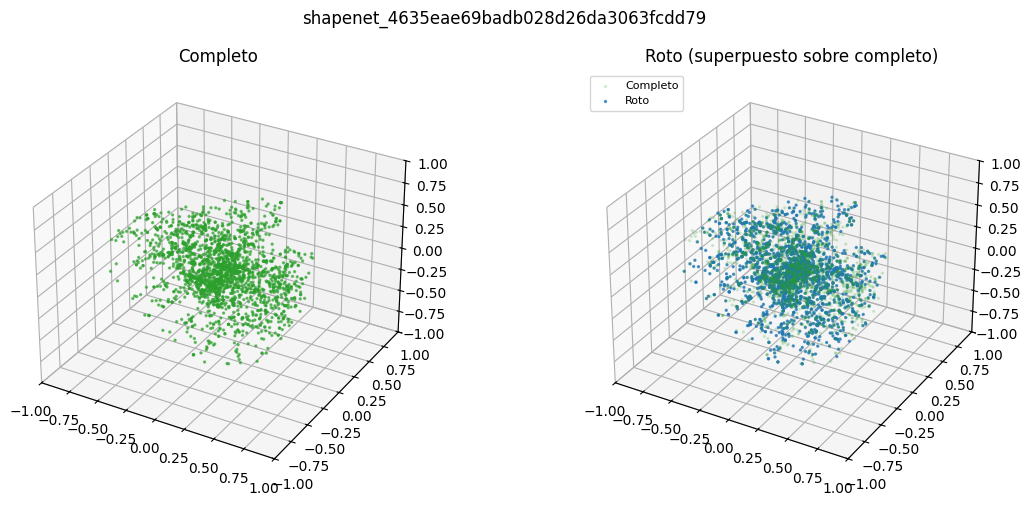

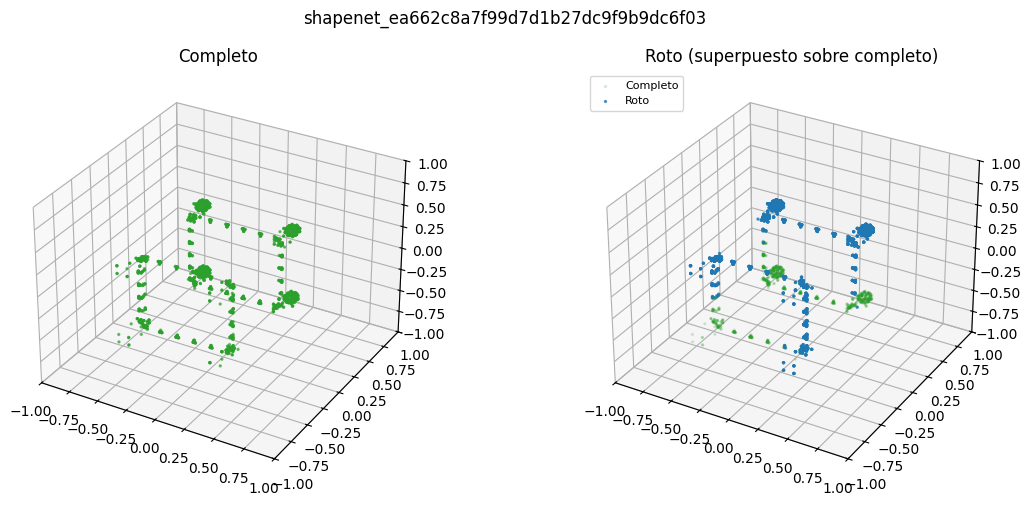

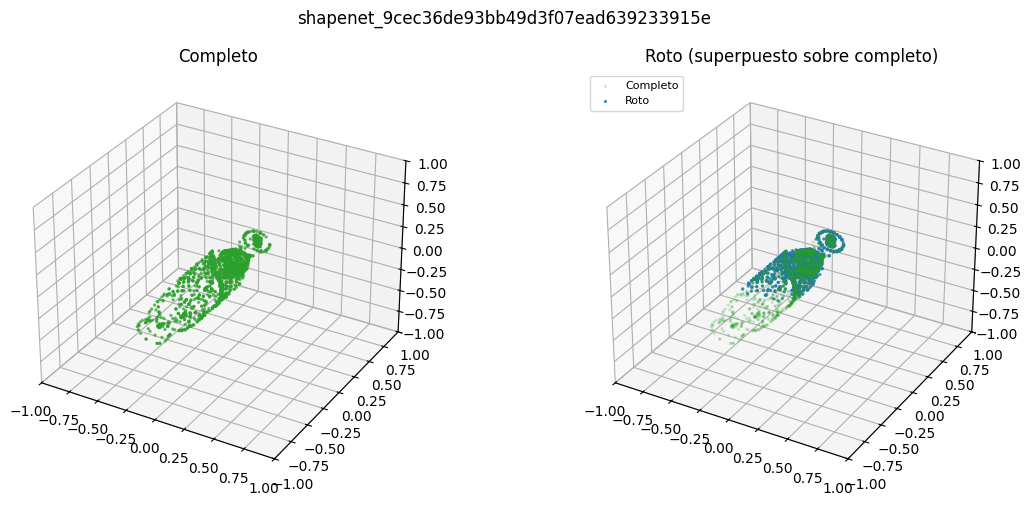

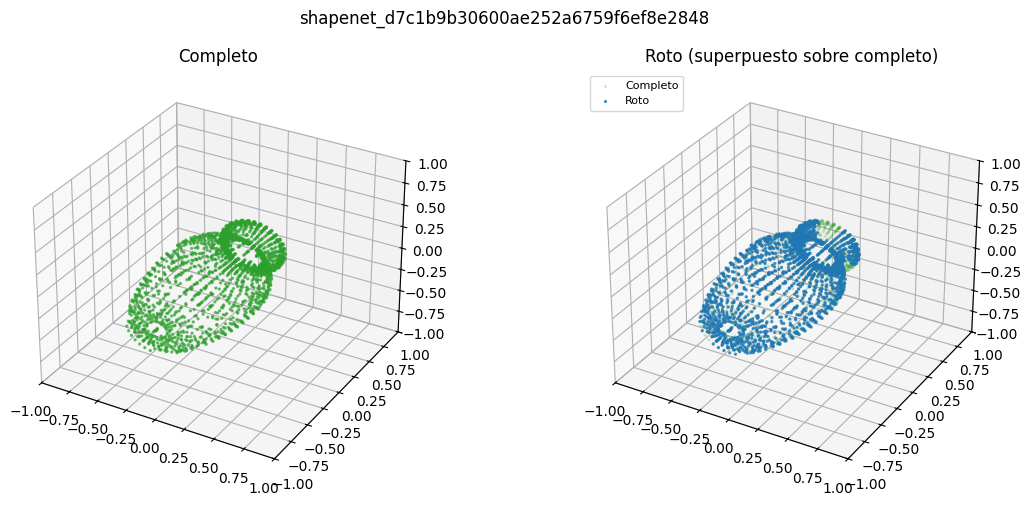

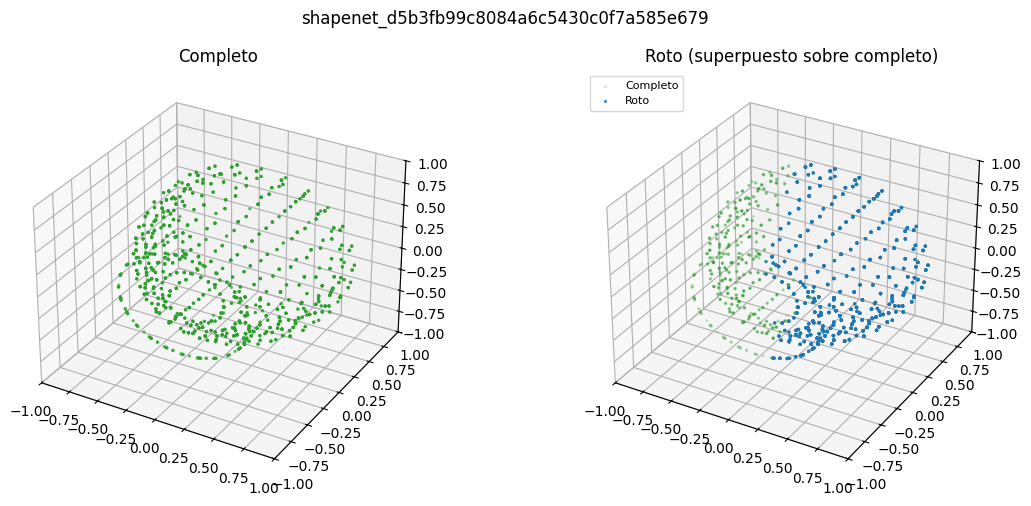

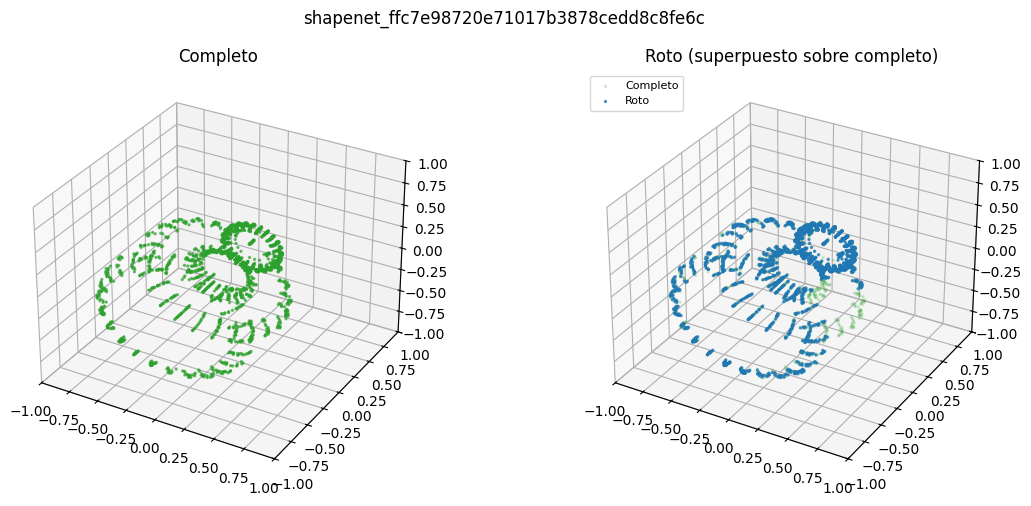

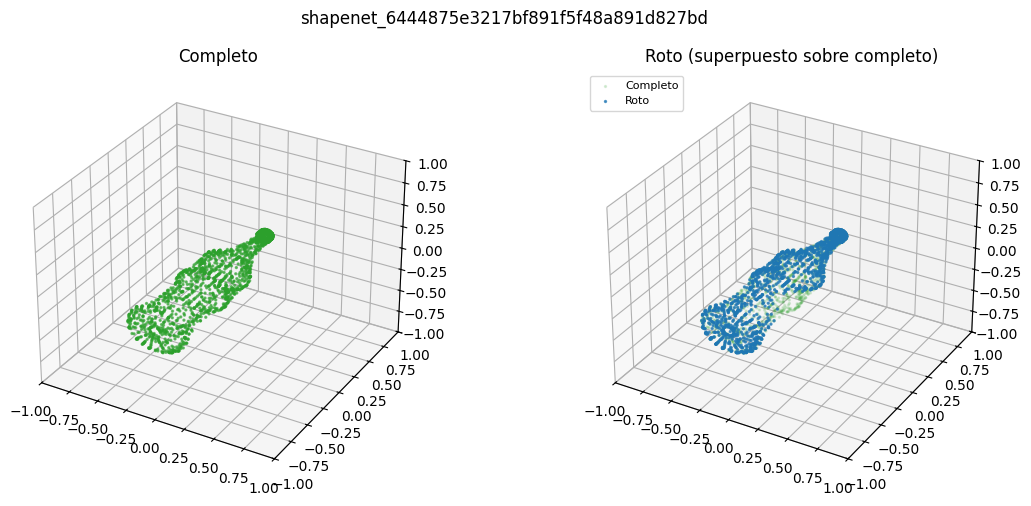

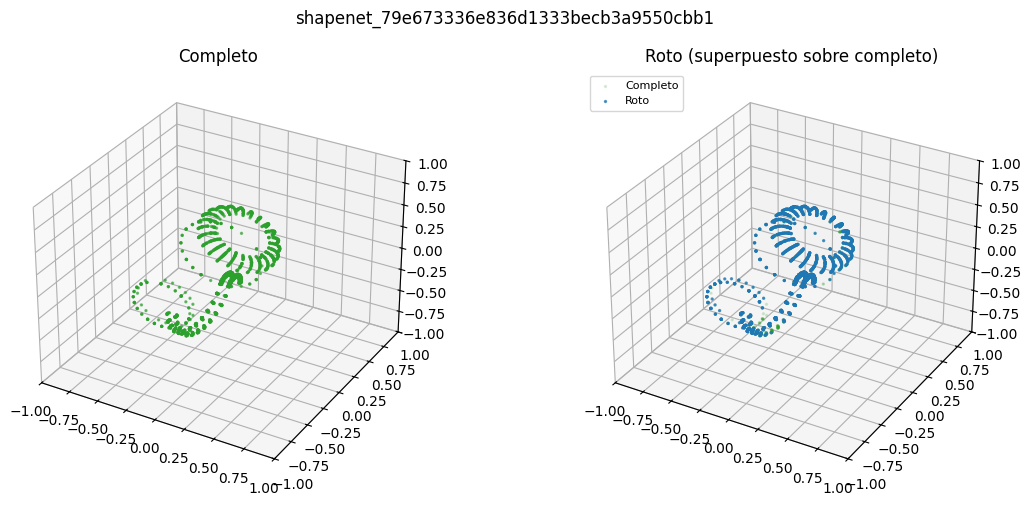

In [9]:
# -- Visualizar ejemplos de sintetico_roturas_v3 --
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

dest = Path(RUTA_SALIDA)
pares = sorted(dest.glob('*_completo.npy'))

N_EJEMPLOS = 8
rng_vis = np.random.default_rng()  # sin semilla fija -> cada vez que ejecutes veras ejemplos distintos
muestra = rng_vis.choice(len(pares), size=min(N_EJEMPLOS, len(pares)), replace=False)

for idx in muestra:
    ruta_c = pares[idx]
    ruta_r = ruta_c.with_name(ruta_c.name.replace('_completo.npy', '_roto.npy'))
    completo = np.load(ruta_c)
    roto = np.load(ruta_r)

    fig = plt.figure(figsize=(12, 5))

    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax1.scatter(completo[:, 0], completo[:, 1], completo[:, 2], s=2, alpha=0.6, color='tab:green')
    ax1.set_title("Completo")

    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    ax2.scatter(completo[:, 0], completo[:, 1], completo[:, 2], s=2, alpha=0.15, color='tab:green', label='Completo')
    ax2.scatter(roto[:, 0], roto[:, 1], roto[:, 2], s=2, alpha=0.7, color='tab:blue', label='Roto')
    ax2.set_title("Roto (superpuesto sobre completo)")
    ax2.legend(loc='upper left', fontsize=8)

    for ax in (ax1, ax2):
        ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)

    plt.suptitle(ruta_c.stem.replace('_completo', ''))
    plt.tight_layout()
    plt.show()